In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from dir import *

In [2]:
img_numed_path = os.getcwd()
main_path = os.path.dirname( os.path.dirname(img_numed_path) )
img_path = main_path + "/img/numed/"

In [3]:
def euler_fo(f,tsim,y0,h=0.1,show=False):
    yn = y0
    tn,tf = tsim
    TN = [tn]
    YN = [yn]

    while abs(tf - tn) >= h/2:
        yn = yn + h*f(tn,yn)
        tn += h
        TN.append(tn)
        YN.append(yn)
        if show: print(f"{tn:0.2f} {yn:0.4f} {ye(tn):0.2f}")
        
    return TN,YN

In [7]:
def euler_so_um(f,tsim,ci,h=0.1,show=False):
    yn,un = ci
    tn,tf = tsim
    YN = [yn]
    UN = [un]
    TN = [tn]

    while abs(tf - tn) >= h/2:
        yn = yn + h*un
        un = un + h*f(tn,yn,un)
        tn += h
        TN.append(tn)
        YN.append(yn)
        UN.append(un)
        if show: print(f"{tn:0.2f} {yn:0.4f} {un:0.2f}")
        
    return TN,YN,UN


def euler_so(f,tsim,ci,h=0.1,show=False,latex=False):
    yn,un = ci
    tn,tf = tsim
    YN = [yn]
    UN = [un]
    TN = [tn]
    latex_str = ""

    while abs(tf - tn) >= h/2:
        m = f(tn,yn,un)
        yn = yn + h*un
        un = un + h*m
        tn += h
        TN.append(tn)
        YN.append(yn)
        UN.append(un)
        if show: print(f"{tn:0.2f} {yn:0.4f}")
        if latex: latex_str += f"{tn:0.2f} & {yn:0.6f} \\\\ \n"
    
    if latex: return TN,YN,UN,latex_str
    return TN,YN,UN

## Ejemplo 1

Resolver:

$$ \frac{dy}{dx} = 3t+2 $$

Sujeta a:

$$ y(0) = 5 $$

In [11]:
def f(t,y):
    return 3*t + 2

def ye(t):
    return 3*t**2/2 + 2*t + 5

In [13]:
T, Y = euler_fo(f,[0,0.5], 5, show=True)

0.10 5.2000 5.21
0.20 5.4300 5.46
0.30 5.6900 5.74
0.40 5.9800 6.04
0.50 6.3000 6.38


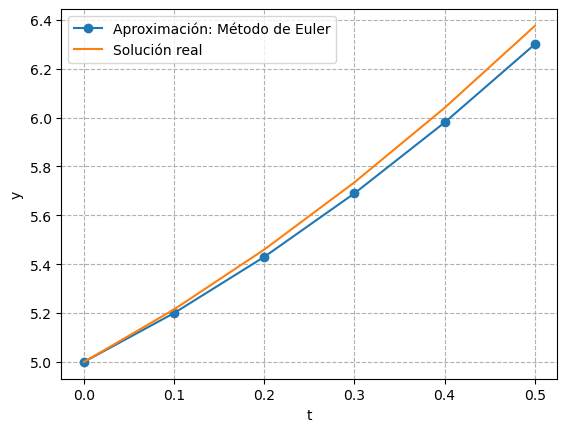

In [17]:
plt.plot(T, Y, "-o", label="Aproximación: Método de Euler")
plt.plot(T, ye(np.array(T)), label="Solución real")
plt.xlabel("t")
plt.ylabel("y")
plt.grid(ls="--")
plt.legend()
plt.savefig(img_path+"euler_numed_example_01.svg")

## Ejemplo 2

In [19]:
def f(t,x,u):
    return -5*u - 4*x

def ye(t):
    return (5/3)*np.exp(-t) - (2/3)*np.exp(-4*t)

In [21]:
h = 0.05
tsim = [0,2]
ci = [1,1]
h = 0.05

T1,Y1,U1 = euler_so(f, tsim, ci, h)

In [23]:
T2,Y2,U2 = euler_so_um(f, tsim, ci, h)

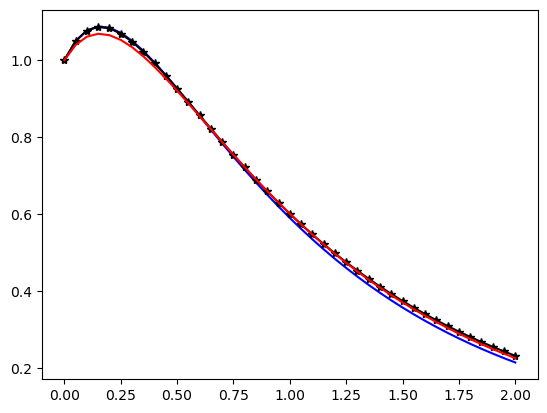

In [25]:
plt.plot(T1, Y1, "b")
plt.plot(T2, Y2, "k-*")
plt.plot(T1, ye(np.array(T1)), "r")

## Ejemplo 3

In [33]:
def f3(t,y,u):
    return -u - 4.25*y

def ye3(t):
    return np.exp(-t/2) * (-np.cos(2*t) + 0.75*np.sin(2*t))

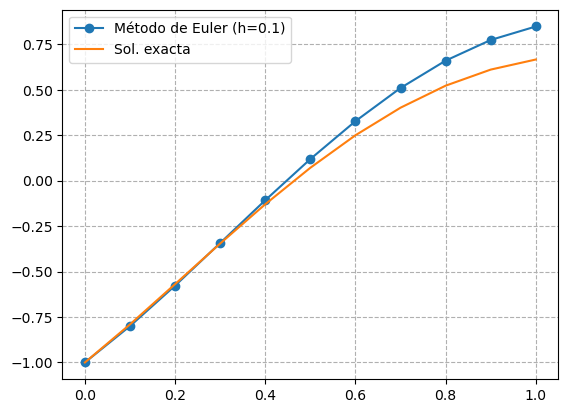

In [35]:
tsim = [0,1]
ci = [-1,2]
h = 0.1

T1,Y1,U1,ltx_tab = euler_so(f3, tsim, ci, h, latex=True)
plt.plot(T1, Y1, "-o", label="Método de Euler (h=0.1)")
plt.plot(T1, ye3(np.array(T1)), label="Sol. exacta")
plt.legend()
plt.grid(ls="--")
plt.savefig(img_path+"/euler_numed_example_03.svg")